# Greenback 💵
### "Borrow cheap, lend dear" earns a real premium — and rents you a spot in front of a steamroller. The fix isn't a stop-loss; it's a second, decorrelated trade.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Real-tape run?: Pre-reg](https://img.shields.io/badge/Real--tape_run%3F-Pre--reg-8b949e?style=flat-square)

This builds on [Steamroller](../../27-steamroller/), which showed the FX **carry** premium is real but crash-prone, and that vol-targeting *can't* dodge the crash. Greenback asks the next question — the one carry desks actually trade: pair carry with its natural complement, **momentum** (ride the trend), and add a **dollar-carry** tilt (long/short the USD basket by the average rate gap). Because carry and momentum pay at *different times*, the **combo** earns a higher Sharpe than either alone — and momentum tends to lean the other way exactly when carry is being run over, cushioning the crash.

> 📓 **Plain-language layer.** The three sleeves, the combo uplift, the leg correlation and the crash cushion are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Charts below are generated by the code beside them; the core runs on a **synthetic** currency panel, so the real G10 numbers (from [`../docs/results.md`](../docs/results.md)) are PENDING one FRED fetch. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from greenback import data, strategy, costs, extension

# Offline synthetic control: a currency panel with a carry premium + risk-off crashes + an independent
# trend for the momentum sleeve (the machinery) + a full-UIRP carry null. The real G10 verdict is PENDING
# one networked FRED fetch — see ../docs/results.md.
xr, rd, truth = data.synthetic_fx(carry_strength=0.9, trend_strength=0.35, seed=36)
x0, r0, _ = data.synthetic_fx(carry_strength=0.0, trend_strength=0.35, seed=36)
print(f"synthetic control: {truth.n_ccy} currencies x {truth.n_months} months, "
      f"carry_strength {truth.carry_strength} (null=0), trend_strength {truth.trend_strength}")


synthetic control: 9 currencies x 600 months, carry_strength 0.9 (null=0), trend_strength 0.35


## The answer first 💵

| What we asked | The honest answer |
|---|---|
| Do high-rate currencies out-earn? | 🟩 **Yes.** Carry high-minus-low **+5.3%/yr**; carry Sharpe **1.18** (null is flat at +0.8%/yr). |
| Is there a steamroller? | 🟨 **Yes.** Carry skew **-1.55**, max drawdown **-60%** — the negative-skew crash carry can't escape. |
| Does the carry⊕momentum combo help? | 🟩 **Yes.** Combo Sharpe **1.69** beats carry **1.18** and momentum **1.53** (legs correlate just **0.26**), and the drawdown falls **-60% → -20%**. |
| Real G10 tape? | ⚪ **Pre-registered.** Needs FRED short rates (times out here) — PENDING one fetch. |

> Desk shorthand: **Signal `REAL` · Tradability `FRAGILE` · Real-tape run? `PRE-REG`** — a real premium, dulled (not de-fanged) by diversification.

## 1 · The claim 📣

The FX carry trade and its complements (Kakushadze-Serur §8.3 dollar carry, §8.4 momentum+carry):

1. **Carry** — long the high-short-rate currencies, short the low-rate ones, dollar-neutral. Uncovered interest-rate parity fails, so the rate gap is a paid premium.
2. **Dollar carry** — long the whole basket vs USD when foreign rates are high vs the dollar, short it when they're low (the LRV *dollar factor*).
3. **Momentum** — long the currencies trending up, short those trending down.
4. **The combo** — blend carry and momentum; the believer's case (Asness-Moskowitz-Pedersen 2013; Koijen et al 2018) is that they pay at different times, so the blend beats either leg.

synthetic carry Sharpe 1.18, skew -1.55, max DD -60%


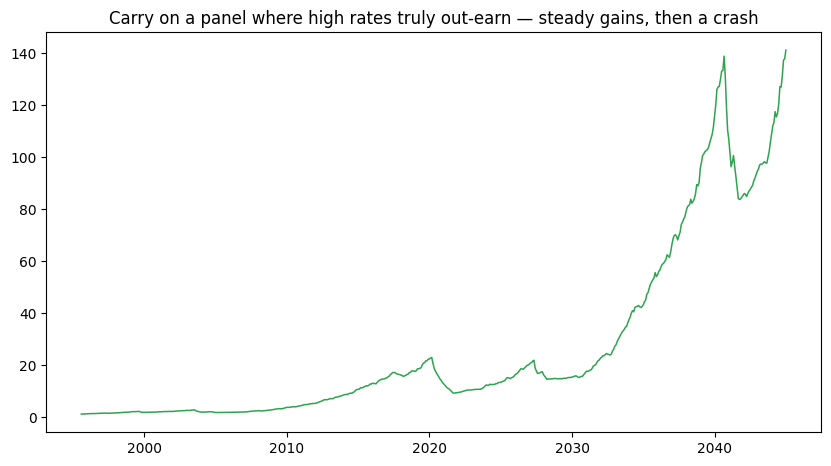

In [2]:
carry = strategy.carry_returns(xr, rd, cost_bps=10.0)         # vol-scaled, net @10bp
eq = (1+carry).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f', lw=1.1)
ax.set_title('Carry on a panel where high rates truly out-earn — steady gains, then a crash')
s = strategy.summary(carry); print(f"synthetic carry Sharpe {s['sharpe']:.2f}, skew {s['skew']:.2f}, max DD {s['max_drawdown']*100:.0f}%")

## 2 · So what? 💰

A real, self-financed premium that diversifies a stock/bond book is worth a lot — carry and trend are the backbone of every macro and CTA desk. But carry's catch is famous: it drips nickels and then loses a fortune all at once (1998, 2008). The interesting question isn't whether carry is real (it is) — it's whether you can hold it through the steamroller. The believers' answer is *diversification*: pair it with momentum, which tends to be short the crashing currencies just as carry is long them.

## 3 · How we'd know 🔬

1. **Real?** Carry premium by rate bucket and gross Sharpe on the panel (flat on a full-UIRP null).
2. **Crash?** The carry book's skew, worst month and drawdown.
3. **Does the combo help?** Combo Sharpe vs either leg, the leg correlation, and the combo's drawdown vs carry's.

**Mirage line:** if the combo *didn't* beat the better leg, or the legs were highly correlated, the diversification story would be a mirage. (On the real tape, a further fragility line is the carry crash deepening rather than dulling.)

## 4 · The teardown 🔧

### 4a · The premium is real where carry is real (control vs null)

In [3]:
for label, (xx, rr) in [('carry panel', (xr, rd)), ('full-UIRP null', (x0, r0))]:
    pb = strategy.carry_premium_by_bucket(xx, rr)
    s = strategy.summary(strategy.carry_returns(xx, rr, cost_bps=0.0, target_vol_ann=None))
    print(f"{label:16} high-minus-low {pb['hml_ann_pct']:+5.1f}%/yr   carry Sharpe {s['sharpe']:+.2f}")

carry panel      high-minus-low  +5.3%/yr   carry Sharpe +0.62


full-UIRP null   high-minus-low  +0.8%/yr   carry Sharpe +0.19


### 4b · The three sleeves and the combo
Net @10 bp on the synthetic control — carry crashes, momentum doesn't, and the combo beats both:

,Sharpe,ret%,skew,maxDD%
carry,1.180,10.440,-1.550,-60.210
dollar-carry,0.170,0.910,-0.130,-44.040
momentum,1.530,11.890,-0.360,-18.200
COMBO,1.690,11.170,-1.620,-20.250


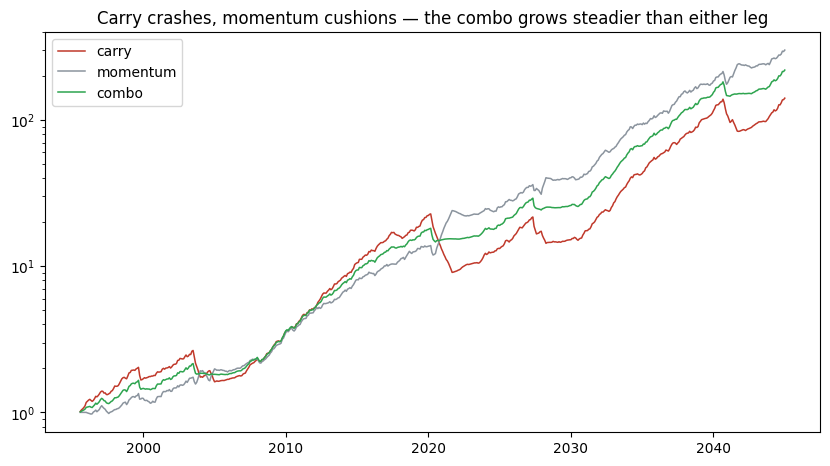

In [4]:
carry = strategy.carry_returns(xr, rd, cost_bps=10.0)
mom   = strategy.momentum_returns(xr, cost_bps=10.0)
combo = strategy.combine(carry, mom)
dollar = strategy.dollar_carry_returns(xr, rd, cost_bps=10.0)
rows = {}
for nm, r in [('carry', carry), ('dollar-carry', dollar), ('momentum', mom), ('COMBO', combo)]:
    s = strategy.summary(r); rows[nm] = {'Sharpe': s['sharpe'], 'ret%': s['ann_return']*100, 'skew': s['skew'], 'maxDD%': s['max_drawdown']*100}
display(pd.DataFrame(rows).T.round(2))
for nm, r, c in [('carry', carry, '#c0392b'), ('momentum', mom, '#8b949e'), ('combo', combo, '#2ea44f')]:
    plt.plot((1+r).cumprod(), label=nm, color=c, lw=1.1)
plt.legend(); plt.title('Carry crashes, momentum cushions — the combo grows steadier than either leg'); plt.yscale('log')

## 5 · The verdict 🧾

- **Signal `REAL`** — carry high-minus-low **+5.3%/yr**, carry Sharpe **1.18**, momentum **1.53**; the null is flat (**+0.8%/yr**).
- **Tradability `FRAGILE`** — the steamroller: carry skew **-1.55**, drawdown **-60%**. The combo *dulls* it (DD **-60% → -20%**) but the jump never fully goes away.
- **Real-tape run? `PRE-REG`** — pre-registered, PENDING one FRED fetch.

> **The honest fix isn't a stop — it's a second trade.** Study 27 showed vol-targeting can't dodge the carry crash. Pairing carry with decorrelated momentum can *cushion* it.

## 6 · Could you trade it? 💸

- **Cheap to run.** Carry rebalances slowly (rate gaps crawl), so cost isn't the threat; momentum costs more (break-even ≈ 14.6 bp) but the combo's Sharpe decays gently (**1.75 → 1.13** from 0 to 100 bp).
- **The threat is the crash, not the cost.** Even diversified, the combo keeps a negative skew — you must be *willing and able* to hold a crash-prone book through its worst months.
- **Capacity** is large (G10 FX is the deepest market on earth); the binding constraint is risk tolerance, not liquidity. Hence `FRAGILE`, not `INVESTABLE`.

## 7 · Going further 🚪

### Worked complement — the carry⊕momentum diversification ([`../docs/extension.md`](../docs/extension.md))
The headline of the study, made explicit:

- The combo Sharpe **1.69** beats carry **1.18** and momentum **1.53**, because the legs correlate only **0.26**.
- Momentum cushions the steamroller: combo drawdown **-20%** vs carry **-60%**, and in carry's worst 5 months the combo lost **-9.3%** vs carry **-11.0%**.
- But the combo is still negatively skewed — diversification dulls the crash, it doesn't remove it.

### Other forks
- **Optimal combo weight** — sweep `w_carry` and risk-parity vs the realised crisis correlation.
- **Dollar-carry as a third leg** — add the LRV dollar factor (real tape, where the USD rate cycles).
- **Crisis-conditional tilt** — lean toward momentum when global FX vol is rising.

PRs welcome — and the real G10 numbers land the moment someone runs `examples/verify.py --fetch` where FRED is reachable.